# Tracing a phase boundary with path following

The boundary between the one-phase and two-phase regions of a mixture — the **phase
envelope** — is a curve that parameter continuation cannot follow. It doubles back on
itself in pressure at the *cricondenbar* and in temperature at the *cricondentherm*, so
"solve at the next pressure" runs out of solutions while the curve is still going.

This notebook builds the envelope of a natural-gas mixture from the Peng–Robinson
equation of state and traces it with
[`pounce.jax.PathFollower`](https://kitchingroup.cheme.cmu.edu/pounce/path-following.html).
Three things come out of it:

- the equilibrium condition is a **square nonlinear system**, posed to POUNCE the way
  `solve_bvp` poses collocation — as the feasibility NLP `min 0` s.t. `F(X) = 0`
  ([bvp.md](https://kitchingroup.cheme.cmu.edu/pounce/bvp.html));
- the **sensitivity is the algorithm**. The tangent `∂X*/∂θ` is what steps the trace,
  and it is also the physically meaningful slope `dT/dP` of the phase boundary — which
  is exactly what diverges at the turning point;
- `PathTrace.turning_points` hands back the cricondenbar and the cricondentherm as
  *detected* output. They are not post-processed maxima; they are where the continuation
  noticed the curve reverse.

Two of the three methods tried here fail, and one of them **fails silently**. That is
kept in, because it is the most useful thing in the notebook.

In [1]:
%matplotlib inline
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pounce
from pounce.jax import JaxProblem, PathFollower   # importing pounce.jax enables x64

print(f"pounce {pounce.__version__}")

pounce 0.10.0


## 1. The mixture and the equilibrium condition

A light natural gas: 80% methane with a heavy tail. The tail is what gives the envelope
its pronounced retrograde region, and therefore its turning points.

At equilibrium the two phases have equal fugacities. Writing $K_i = y_i/x_i$ for the
equilibrium ratios and fixing the vapor fraction $\beta$, the incipient-phase condition
of Michelsen (*Fluid Phase Equilibria* **4**, 1–10, 1980) is

$$
x_i = \frac{z_i}{1-\beta+\beta K_i}, \qquad y_i = K_i x_i,
$$
$$
g_i = \ln K_i + \ln\varphi_i^{\,\mathrm{v}}(\mathbf{y},T,P)
              - \ln\varphi_i^{\,\mathrm{l}}(\mathbf{x},T,P) = 0,
\qquad i = 1\ldots N,
$$
$$
g_{N+1} = \sum_i (y_i - x_i) = 0 .
$$

That is $N+1$ equations. With unknowns $X = [\ln K_1,\ldots,\ln K_N,\ \ln T]$ and the
pressure carried as the continuation parameter $\theta = \ln P$, the system is **square**
— and the solutions as $\theta$ varies sweep out the phase envelope. Everything is in
logs, which keeps $K$, $T$ and $P$ positive without bounds and conditions the Jacobian.

$\beta = 1$ makes the feed the vapor, so the curve starts as the **dew** locus. Keep an
eye on that word: it does not survive the whole trace.

In [2]:
R = 8.314462618  # J/mol/K

NAMES = ["methane", "ethane", "propane", "n-butane"]
TC = jnp.array([190.6, 305.3, 369.8, 425.1])         # K
PC = jnp.array([45.99, 48.72, 42.48, 37.96]) * 1e5   # Pa
OM = jnp.array([0.012, 0.100, 0.152, 0.200])         # acentric factor
Z_FEED = jnp.array([0.80, 0.10, 0.06, 0.04])         # feed mole fractions
N = 4

print(f"{'component':<10} {'z':>6} {'Tc (K)':>8} {'Pc (bar)':>9} {'omega':>7}")
print("-" * 44)
for i, nm in enumerate(NAMES):
    print(f"{nm:<10} {Z_FEED[i]:6.2f} {TC[i]:8.1f} {PC[i]/1e5:9.2f} {OM[i]:7.3f}")
print("\nBinary interaction parameters k_ij = 0 (all light alkanes).")

component       z   Tc (K)  Pc (bar)   omega
--------------------------------------------
methane      0.80    190.6     45.99   0.012
ethane       0.10    305.3     48.72   0.100
propane      0.06    369.8     42.48   0.152
n-butane     0.04    425.1     37.96   0.200

Binary interaction parameters k_ij = 0 (all light alkanes).


## 2. Peng–Robinson, differentiably

$$
Z^3 - (1-B)Z^2 + (A - 2B - 3B^2)Z - (AB - B^2 - B^3) = 0
$$

Two choices here decide whether any of this works.

**The cubic is solved in closed form.** An iterative root-find or `np.roots` would break
the autodiff chain; the trigonometric Cardano form keeps the whole residual one
differentiable expression.

**Both branches of the root formula are sanitized before the `sqrt`/`arccos`.** Under
`jax.jacobian` the one-real-root and three-real-root branches are *both* evaluated, and a
`NaN` produced in the dead branch propagates into the gradient of the live one even
though `jnp.where` discards its value. Clamping the argument inside each branch — the
double-`where` — is what keeps the Jacobian finite. Cell 3 checks that it does.

The vapor phase takes the largest real root and the liquid the smallest. Selecting
instead by lowest Gibbs energy is the textbook rule, but it introduces a switch that puts
a kink in the path and stalls the corrector; largest/smallest-$Z$ is what continuation
codes use.

In [3]:
def cubic_real_root(c2, c1, c0, largest: bool):
    """Real root of Z^3 + c2 Z^2 + c1 Z + c0 = 0, in closed form.

    Returns the largest (vapor) or smallest (liquid) real root when three
    exist, and the unique real root otherwise. Each branch clamps its own
    argument *before* the sqrt/arccos so that autodiff through the dead
    branch cannot inject NaNs into the live one.
    """
    p = c1 - c2**2 / 3.0
    q = 2.0 * c2**3 / 27.0 - c2 * c1 / 3.0 + c0
    D = (q / 2.0) ** 2 + (p / 3.0) ** 3
    three = D <= 0.0

    # one real root (D > 0): keep the sqrt argument non-negative
    D_safe = jnp.where(three, 1.0, D)
    sD = jnp.sqrt(D_safe)
    t_one = jnp.cbrt(-q / 2.0 + sD) + jnp.cbrt(-q / 2.0 - sD)

    # three real roots (D <= 0, which forces p <= 0): keep p strictly negative
    p_safe = jnp.where(three, jnp.minimum(p, -1e-300), -1.0)
    r = 2.0 * jnp.sqrt(-p_safe / 3.0)
    arg = jnp.clip((3.0 * q) / (2.0 * p_safe) * jnp.sqrt(-3.0 / p_safe), -1.0, 1.0)
    phi = jnp.arccos(arg) / 3.0
    t0 = r * jnp.cos(phi)
    t1 = r * jnp.cos(phi - 2.0 * jnp.pi / 3.0)
    t2 = r * jnp.cos(phi - 4.0 * jnp.pi / 3.0)
    t_three = (jnp.maximum(jnp.maximum(t0, t1), t2) if largest
               else jnp.minimum(jnp.minimum(t0, t1), t2))

    return jnp.where(three, t_three, t_one) - c2 / 3.0


def _ab(T):
    kappa = 0.37464 + 1.54226 * OM - 0.26992 * OM**2
    alpha = (1.0 + kappa * (1.0 - jnp.sqrt(T / TC))) ** 2
    ai = 0.45724 * R**2 * TC**2 * alpha / PC
    bi = 0.07780 * R * TC / PC
    return ai, bi


def compressibility(w, T, P, largest: bool):
    """PR compressibility factor for composition w at (T, P)."""
    ai, bi = _ab(T)
    sa = jnp.sqrt(ai)
    a = w @ jnp.outer(sa, sa) @ w      # k_ij = 0
    b = w @ bi
    A, B = a * P / (R * T) ** 2, b * P / (R * T)
    return cubic_real_root(-(1.0 - B), A - 2.0 * B - 3.0 * B**2,
                           -(A * B - B**2 - B**3), largest)


def ln_phi(w, T, P, largest: bool):
    """PR log fugacity coefficients for composition w at (T, P)."""
    ai, bi = _ab(T)
    sa = jnp.sqrt(ai)
    aij = jnp.outer(sa, sa)
    a = w @ aij @ w
    b = w @ bi
    A, B = a * P / (R * T) ** 2, b * P / (R * T)
    Z = cubic_real_root(-(1.0 - B), A - 2.0 * B - 3.0 * B**2,
                        -(A * B - B**2 - B**3), largest)
    s2 = jnp.sqrt(2.0)
    return ((bi / b) * (Z - 1.0) - jnp.log(Z - B)
            - A / (2.0 * s2 * B) * (2.0 * (aij @ w) / a - bi / b)
            * jnp.log((Z + (1.0 + s2) * B) / (Z + (1.0 - s2) * B)))

### Does the EOS actually work?

Three checks before anything is built on top of it: the ideal-gas limit, a pure-component
vapor pressure against literature values, and — the one that matters for what follows —
that gradients stay finite in the region where the cubic has one real root *and* in the
region where it has three.

In [4]:
print("ideal-gas limit, Z -> 1 as P -> 0 (feed composition, 300 K):")
for P in [1e3, 1e4, 1e5]:
    print(f"  P = {P:8.1e} Pa   Z_vap = {float(compressibility(Z_FEED, 300.0, P, True)):.6f}")

print("\ngradients through both cubic branches (no NaNs):")
for P, T, tag in [(1e5, 300.0, "one real root"), (1e6, 200.0, "three real roots")]:
    dv = float(jax.grad(lambda t: compressibility(Z_FEED, t, P, True))(T))
    dl = float(jax.grad(lambda t: compressibility(Z_FEED, t, P, False))(T))
    print(f"  {tag:18s} dZ_vap/dT = {dv: .4e}   dZ_liq/dT = {dl: .4e}")

print("\npure n-butane vapor pressure (equal fugacity), vs literature:")
pure_nc4 = jnp.array([0.0, 0.0, 0.0, 1.0])

def dlnf(lnP, T):
    P = jnp.exp(lnP)
    return float(ln_phi(pure_nc4, T, P, True)[3] - ln_phi(pure_nc4, T, P, False)[3])

for T, lit in [(273.15, 1.03), (300.0, 2.58), (350.0, 9.42)]:
    lo, hi = np.log(1e3), np.log(3.5e6)
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        lo, hi = (lo, mid) if dlnf(mid, T) * dlnf(lo, T) <= 0 else (mid, hi)
    print(f"  T = {T:7.2f} K   Psat = {np.exp(0.5*(lo+hi))/1e5:6.3f} bar   (lit ~{lit} bar)")

ideal-gas limit, Z -> 1 as P -> 0 (feed composition, 300 K):


  P =  1.0e+03 Pa   Z_vap = 0.999963
  P =  1.0e+04 Pa   Z_vap = 0.999630
  P =  1.0e+05 Pa   Z_vap = 0.996300

gradients through both cubic branches (no NaNs):


  one real root      dZ_vap/dT =  3.7931e-05   dZ_liq/dT =  3.7931e-05
  three real roots   dZ_vap/dT =  1.8885e-03   dZ_liq/dT =  3.4964e-04

pure n-butane vapor pressure (equal fugacity), vs literature:


  T =  273.15 K   Psat =  1.034 bar   (lit ~1.03 bar)


  T =  300.00 K   Psat =  2.573 bar   (lit ~2.58 bar)


  T =  350.00 K   Psat =  9.469 bar   (lit ~9.42 bar)


## 3. The square system, posed to POUNCE

POUNCE has no `root()` entry point, and it does not need one. A square system is a
**feasibility NLP**: minimise nothing, subject to $F(X)=0$. This is exactly how
`pounce.solve_bvp` poses its collocation residual internally. For a square nonsingular
$J = \partial F/\partial X$ the KKT stationarity $J^{\mathsf T}\lambda = 0$ forces
$\lambda^*=0$, so the interior-point step collapses to $\Delta X = -J^{-1}F$ — the Newton
step, with the barrier machinery contributing nothing.

The parameter is declared with shape `(1,)`: `PathFollower.trace_arclength` requires a
**scalar** continuation parameter.

In [5]:
def envelope_residual(X, lnP, beta):
    """Michelsen phase-envelope residual. X = [lnK_1..lnK_N, lnT], theta = lnP."""
    lnK, lnT = X[:N], X[N]
    K, T, P = jnp.exp(lnK), jnp.exp(lnT), jnp.exp(lnP)
    x = Z_FEED / (1.0 - beta + beta * K)     # heavy (liquid-like) phase
    y = K * x                                # light (vapor-like) phase
    gi = lnK + ln_phi(y, T, P, largest=True) - ln_phi(x, T, P, largest=False)
    return jnp.concatenate([gi, jnp.array([jnp.sum(y - x)])])


def make_problem(beta):
    """min 0  s.t.  F(X; lnP) = 0 -- a square system as a feasibility NLP."""
    return JaxProblem(
        f=lambda X, p: 0.0 * jnp.sum(X),                  # zero objective
        g=lambda X, p: envelope_residual(X, jnp.reshape(p, ()), beta),
        n=N + 1, m=N + 1,
        p_example=jnp.zeros(1),                           # scalar theta = lnP
        cl=jnp.zeros(N + 1), cu=jnp.zeros(N + 1),
        options={"tol": 1e-10, "print_level": 0, "sb": "yes"},
    )


BETA = 1.0                 # feed is the vapor: the curve starts on the dew locus
jp = make_problem(BETA)
print(f"n = {N+1} unknowns, m = {N+1} equations -- square")

n = 5 unknowns, m = 5 equations -- square


## 4. The easy starting point

Continuation needs somewhere to start, and at low pressure the mixture is nearly ideal,
so the Wilson correlation

$$\ln K_i = \ln(P_{c,i}/P) + 5.373\,(1+\omega_i)(1 - T_{c,i}/T)$$

is a good enough guess to converge from. At $P = 1$ bar the dew temperature follows from
a scalar bisection on $\sum_i z_i/K_i(T) = 1$ — one line, no derivatives — and the full
system then converges from there.

In [6]:
def wilson_lnK(T, P):
    return jnp.log(PC / P) + 5.373 * (1.0 + OM) * (1.0 - TC / T)


def wilson_start(P0, beta):
    """Wilson K-values + a scalar bisection for the incipient-phase temperature."""
    if beta == 1.0:      # dew: sum z_i / K_i = 1
        r = lambda T: float(jnp.sum(Z_FEED / jnp.exp(wilson_lnK(T, P0))) - 1.0)
    else:                # bubble: sum z_i K_i = 1
        r = lambda T: float(jnp.sum(Z_FEED * jnp.exp(wilson_lnK(T, P0))) - 1.0)
    lo, hi = 100.0, 600.0
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        lo, hi = (lo, mid) if r(mid) * r(lo) <= 0 else (mid, hi)
    T0 = 0.5 * (lo + hi)
    return jnp.concatenate([wilson_lnK(T0, P0), jnp.array([jnp.log(T0)])]), T0


P0 = 1e5                                   # 1 bar
lnP0 = float(np.log(P0))
X_guess, T_wilson = wilson_start(P0, BETA)
X_start = jp.solve(jnp.array([lnP0]), X_guess)

res0 = float(jnp.max(jnp.abs(envelope_residual(X_start, lnP0, BETA))))
print(f"Wilson guess  : T = {T_wilson:.2f} K")
print(f"converged     : T = {float(jnp.exp(X_start[N])):.3f} K at P = {P0/1e5:.2f} bar")
print(f"max|F|        : {res0:.2e}")
print(f"K-values      : {np.array2string(np.exp(np.asarray(X_start[:N])), precision=4)}")

Wilson guess  : T = 209.58 K
converged     : T = 211.684 K at P = 1.00 bar
max|F|        : 1.94e-13
K-values      : [6.6123e+01 3.4459e+00 4.0889e-01 4.9252e-02]


## 5. Attempt 1 — walk up in pressure

The obvious thing: raise the pressure a step at a time, warm-starting each solve from the
last converged point. This is what a parameter sweep looks like, and on the lower part of
the curve it works fine.

In [7]:
Xk, ladder, last_good = X_start, [], None
for Pq in np.concatenate([np.linspace(1, 90, 30), np.linspace(92, 105, 14)]):
    lnPq = float(np.log(Pq * 1e5))
    Xn = jp.solve(jnp.array([lnPq]), Xk)
    r = float(jnp.max(jnp.abs(envelope_residual(Xn, lnPq, BETA))))
    if r > 1e-8 or not np.all(np.isfinite(np.asarray(Xn))):
        print(f"FAILED at P = {Pq:.2f} bar   (residual {r:.2e})")
        print(f"last good point: P = {last_good[0]:.2f} bar, T = {last_good[1]:.2f} K")
        break
    Xk = Xn
    last_good = (Pq, float(jnp.exp(Xn[N])))
    ladder.append(last_good)
else:
    print("the ladder never failed")

ladder = np.array(ladder)
print(f"\n{len(ladder)} points climbed, from {ladder[0,0]:.2f} to {ladder[-1,0]:.2f} bar")

FAILED at P = 98.00 bar   (residual 2.17e-04)
last good point: P = 97.00 bar, T = 266.08 K

36 points climbed, from 1.00 to 97.00 bar


It dies. Nothing is wrong with the solver or the starting point: **there is no solution**
at the next pressure. The curve has a maximum in $P$, and the ladder walked into it.

That maximum is a real, named quantity — the *cricondenbar*, the highest pressure at
which two phases can coexist for this mixture. Keep the number in mind; it will come back
as an output rather than an obstacle.

## 6. Attempt 2 — `PathFollower.follow`

`follow` traces $X^*(\theta(s))$ along a **prescribed** path in the parameter, predicting
along the held-factor sensitivity and correcting only when the KKT residual drifts. Since
the ladder above failed by re-solving badly, a predictor-corrector ought to do better.

It reports success.

In [8]:
lnP_end = float(np.log(105e5))
pf = PathFollower(jp, monitor_tol=1e-6, ds0=0.05, ds_max=0.2)
tr_follow = pf.follow(lambda u: jnp.array([lnP0 + u * (lnP_end - lnP0)]),
                      (0.0, 1.0), X_start)

P_f = np.exp(tr_follow.theta.reshape(-1)) / 1e5
T_f = np.exp(tr_follow.x[:, N])
print(f"status = {tr_follow.status}   steps = {tr_follow.n_steps}   "
      f"correctors = {tr_follow.n_correctors}   accepts = {tr_follow.n_accepts}")
print(f"reached P = {P_f.max():.2f} bar of the requested 105.00 bar\n")

print(f"{'P (bar)':>9} {'T (K)':>9} {'K_C1':>9} {'K_C2':>9} {'K_C3':>9} {'K_nC4':>9} {'max|F|':>10}")
print("-" * 70)
for k in range(len(P_f)):
    lnPk = float(tr_follow.theta.reshape(-1)[k])
    r = float(jnp.max(jnp.abs(envelope_residual(jnp.asarray(tr_follow.x[k]), lnPk, BETA))))
    K = np.exp(tr_follow.x[k, :N])
    print(f"{P_f[k]:9.3f} {T_f[k]:9.3f} {K[0]:9.4f} {K[1]:9.4f} {K[2]:9.4f} {K[3]:9.4f} {r:10.1e}")

status = ok   steps = 9   correctors = 8   accepts = 0
reached P = 105.00 bar of the requested 105.00 bar

  P (bar)     T (K)      K_C1      K_C2      K_C3     K_nC4     max|F|
----------------------------------------------------------------------
    1.000   211.684   66.1229    3.4459    0.4089    0.0493    1.9e-13
    1.262   215.296   55.6727    3.1362    0.3929    0.0499    2.4e-13
    1.789   220.963   42.9527    2.7235    0.3705    0.0511    5.5e-13
    3.020   230.044   29.0001    2.2049    0.3405    0.0533    3.7e-11
    6.624   244.968   15.9043    1.6087    0.3036    0.0580    1.6e-14
   16.801   264.098    7.5817    1.1143    0.2744    0.0683    8.4e-14
   42.617   281.105    3.3914    0.7934    0.2741    0.0954    1.8e-15
   66.894   283.721    2.1666    0.7017    0.3082    0.1362    1.8e-15
  105.000   256.778    1.0000    1.0000    1.0000    1.0000    2.2e-15


Look at the last row. Every $K_i = 1$, and the residual is $10^{-15}$.

$K_i = 1$ means $\mathbf{x} = \mathbf{y} = \mathbf{z}$: the two phases have identical
compositions, which is to say *there is no phase split*. This is the **trivial solution**,
and it satisfies the equilibrium equations exactly at every temperature and pressure —
put $\ln K_i = 0$ into $g_i$ and both fugacity terms cancel; put $x = y$ into $g_{N+1}$
and the sum is zero. It is a solution of the algebra that is not a phase boundary.

So `follow` did not fail. It converged, to machine precision, onto a solution branch that
carries no physics — and reported `status="ok"` while doing it. The KKT monitor cannot
catch this, because there is genuinely nothing wrong with the point it landed on.

**This is the failure mode to worry about.** The ladder in section 5 failed loudly; this
one failed silently, and a plot of $T$ against $P$ would have looked plausible. Any
continuation on a system with a trivial branch needs the trivial branch watched
explicitly — here, `max|ln K|` collapsing to zero away from the critical point.

## 7. Attempt 3 — pseudo-arclength

Both failures trace to the same cause: $\theta$ was treated as the independent variable.
At the cricondenbar $\partial X^*/\partial\theta$ is singular and the curve doubles back,
so no method that marches in $\theta$ has anywhere to go.

`trace_arclength` parametrises the solution curve by its own **arclength** instead,
solving $R(X,\lambda,\theta) = 0$ in $(X,\lambda,\theta)$ space with an SVD tangent
predictor and a Newton corrector on the augmented system. Arclength never reverses, so
the fold is just another point on the walk — and because the trace steps *along the
tangent* rather than re-solving from scratch, it cannot fall onto the trivial branch.

In [9]:
tr = PathFollower(jp).trace_arclength(X_start, lnP0, ds=0.05, n_steps=400, direction=1.0)

P = np.exp(tr.theta) / 1e5
T = np.exp(tr.x[:, N])
lnK_max = np.max(np.abs(tr.x[:, :N]), axis=1)

print(f"status = {tr.status}   steps = {tr.n_steps}   arclength = {tr.s[-1]:.2f}")
print(f"P range: {P.min():.3f} .. {P.max():.2f} bar")
print(f"T range: {T.min():.2f} .. {T.max():.2f} K")
print()
print(f"turning_points (theta = lnP) -> "
      f"{[f'{np.exp(t)/1e5:.2f} bar' for t in tr.turning_points]}")
print(f"  ... the CRICONDENBAR, detected where the theta-component of the tangent")
print(f"      changed sign. The ladder in section 5 died at 98 bar.")

status = corrector_failed   steps = 323   arclength = 16.15
P range: 1.000 .. 97.58 bar
T range: 182.96 .. 283.93 K

turning_points (theta = lnP) -> ['97.58 bar']
  ... the CRICONDENBAR, detected where the theta-component of the tangent
      changed sign. The ladder in section 5 died at 98 bar.


The full envelope, coloured by arclength so the trace reads as one continuous walk.

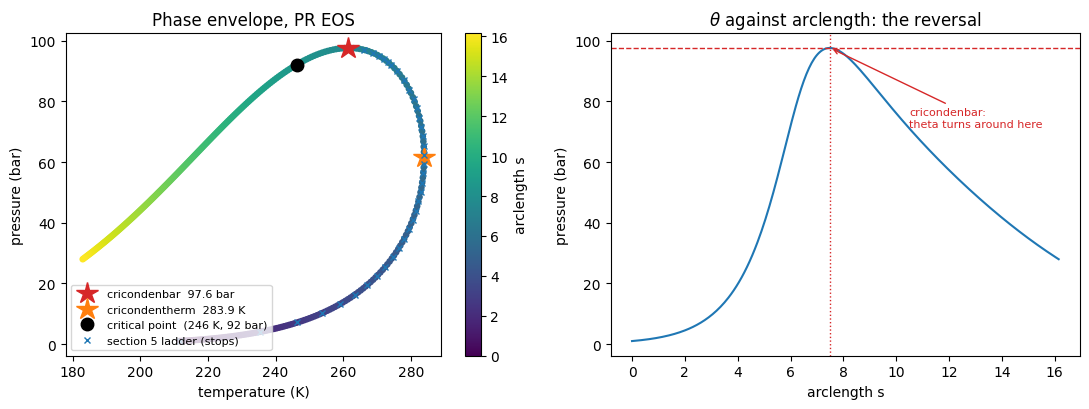

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

sc = ax[0].scatter(T, P, c=tr.s, cmap="viridis", s=14, zorder=3)
ax[0].plot(T, P, "-", color="0.75", lw=0.8, zorder=2)
icb = int(np.argmax(P))
ict = int(np.argmax(T))
icrit = int(np.argmin(lnK_max))
ax[0].plot(T[icb], P[icb], "*", ms=16, color="C3", zorder=4,
           label=f"cricondenbar  {P[icb]:.1f} bar")
ax[0].plot(T[ict], P[ict], "*", ms=16, color="C1", zorder=4,
           label=f"cricondentherm  {T[ict]:.1f} K")
ax[0].plot(T[icrit], P[icrit], "o", ms=9, color="k", zorder=4,
           label=f"critical point  ({T[icrit]:.0f} K, {P[icrit]:.0f} bar)")
ax[0].plot(ladder[:, 1], ladder[:, 0], "x", color="C0", ms=4, zorder=5,
           label="section 5 ladder (stops)")
ax[0].set_xlabel("temperature (K)")
ax[0].set_ylabel("pressure (bar)")
ax[0].set_title("Phase envelope, PR EOS")
ax[0].legend(fontsize=8, loc="lower left")
fig.colorbar(sc, ax=ax[0], label="arclength s")

ax[1].plot(tr.s, P, "-", color="C0")
for t in tr.turning_points:
    ax[1].axhline(np.exp(t) / 1e5, color="C3", ls="--", lw=1)
    ax[1].axvline(tr.s[icb], color="C3", ls=":", lw=1)
ax[1].set_xlabel("arclength s")
ax[1].set_ylabel("pressure (bar)")
ax[1].set_title(r"$\theta$ against arclength: the reversal")
ax[1].annotate("cricondenbar:\ntheta turns around here",
               xy=(tr.s[icb], P[icb]), xytext=(tr.s[icb] + 3.0, P[icb] - 26),
               arrowprops=dict(arrowstyle="->", color="C3"), fontsize=8, color="C3")
fig.tight_layout()
plt.show()

The right panel is the whole argument in one line. Pressure rises, reverses, and falls
again. At that reversal a method marching in $P$ has nowhere to go — and the two-phase
region *inside* the loop is precisely the answer being computed: outside it the mixture
is a single phase.

## 8. The other turning point

The cricondenbar was detected because pressure was the continuation parameter. Swap the
roles — carry $\ln P$ as a state and continue in $\theta = \ln T$ — and the same
machinery detects the *cricondentherm* instead, the highest temperature at which two
phases coexist.

The two runs are independent parameterizations of the same curve, so each one's detected
turning point must equal the other's plain maximum. That is a real check, not a
restatement.

In [11]:
def make_problem_T(beta):
    """Roles swapped: X = [lnK, lnP], theta = lnT."""
    def g(X, p):
        Xr = jnp.concatenate([X[:N], jnp.reshape(p, (1,))])   # [lnK, lnT]
        return envelope_residual(Xr, X[N], beta)              # lnP is now a state
    return JaxProblem(f=lambda X, p: 0.0 * jnp.sum(X), g=g, n=N + 1, m=N + 1,
                      p_example=jnp.zeros(1),
                      cl=jnp.zeros(N + 1), cu=jnp.zeros(N + 1),
                      options={"tol": 1e-10, "print_level": 0, "sb": "yes"})


jpT = make_problem_T(BETA)
lnT0 = float(X_start[N])
XT_start = jpT.solve(jnp.array([lnT0]),
                     jnp.concatenate([X_start[:N], jnp.array([lnP0])]))
trT = PathFollower(jpT).trace_arclength(XT_start, lnT0, ds=0.05, n_steps=400,
                                        direction=1.0)
P_T = np.exp(trT.x[:, N]) / 1e5

print(f"theta = lnT run: status = {trT.status}, steps = {trT.n_steps}")
print()
print(f"{'quantity':<18} {'detected as a turning point':>30} {'plain max of the other run':>29}")
print("-" * 79)
print(f"{'cricondentherm':<18} "
      f"{f'{np.exp(trT.turning_points[0]):.2f} K':>30} {f'{T.max():.2f} K':>29}")
print(f"{'cricondenbar':<18} "
      f"{f'{np.exp(tr.turning_points[0])/1e5:.2f} bar':>30} {f'{P_T.max():.2f} bar':>29}")
print()
print(f"agreement: {abs(np.exp(trT.turning_points[0]) - T.max()):.3f} K, "
      f"{abs(np.exp(tr.turning_points[0])/1e5 - P_T.max()):.3f} bar "
      f"(turning points are located to the ds sampling resolution)")

theta = lnT run: status = corrector_failed, steps = 323

quantity              detected as a turning point    plain max of the other run
-------------------------------------------------------------------------------
cricondentherm                           283.91 K                      283.93 K
cricondenbar                            97.58 bar                     97.58 bar

agreement: 0.020 K, 0.000 bar (turning points are located to the ds sampling resolution)


## 9. Through the critical point — the trace changes what it is computing

Follow `max|ln K|` along the walk. It starts large, collapses almost to zero, and grows
again. Where it touches zero all $K_i = 1$: the two phases have become identical. That is
the **mixture critical point**.

What happens on the far side is the interesting part. The $K$-values *invert* — methane's
$K$ crosses from above 1 to below 1 — which means the phase carrying the feed composition
switches from being the vapor to being the liquid. The trace started on the dew locus and
came out on the **bubble** locus, without being told to. One continuation, from one
low-pressure starting point, produced the entire envelope.

(This is also why section 6's collapse onto $K \equiv 1$ was so easy to miss: near the
critical point the trivial branch and the physical branch genuinely meet.)

closest sampled point: max|lnK| = 0.00385 at T = 246.26 K, P = 92.11 bar
parabola-refined     : T_c = 246.32 K, P_c = 92.14 bar
K-values there       : [0.99946 1.00126 1.00257 1.00386]

                  K_C1      K_C2      K_C3     K_nC4   phase carrying the feed
----------------------------------------------------------------------------
before           1.241     0.754     0.526     0.368   vapor  -> DEW branch
after            0.906     1.410     1.948     2.684   liquid -> BUBBLE branch


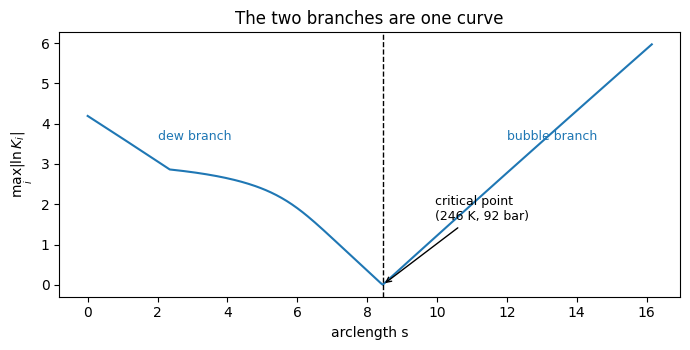

In [12]:
icrit = int(np.argmin(lnK_max))
sl = slice(icrit - 3, icrit + 4)
c = np.polyfit(tr.s[sl], lnK_max[sl], 2)
s_crit = -c[1] / (2 * c[0])
T_crit = np.interp(s_crit, tr.s, T)
P_crit = np.interp(s_crit, tr.s, P)

print(f"closest sampled point: max|lnK| = {lnK_max[icrit]:.5f} "
      f"at T = {T[icrit]:.2f} K, P = {P[icrit]:.2f} bar")
print(f"parabola-refined     : T_c = {T_crit:.2f} K, P_c = {P_crit:.2f} bar")
print(f"K-values there       : {np.array2string(np.exp(tr.x[icrit, :N]), precision=5)}")
print()
print(f"{'':<12} {'K_C1':>9} {'K_C2':>9} {'K_C3':>9} {'K_nC4':>9}   phase carrying the feed")
print("-" * 76)
kb = np.exp(tr.x[icrit - 25, :N])
ka = np.exp(tr.x[icrit + 25, :N])
print(f"{'before':<12} {kb[0]:9.3f} {kb[1]:9.3f} {kb[2]:9.3f} {kb[3]:9.3f}   "
      f"vapor  -> DEW branch")
print(f"{'after':<12} {ka[0]:9.3f} {ka[1]:9.3f} {ka[2]:9.3f} {ka[3]:9.3f}   "
      f"liquid -> BUBBLE branch")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(tr.s, lnK_max, "-", color="C0")
ax.axvline(s_crit, color="k", ls="--", lw=1)
ax.annotate(f"critical point\n({T_crit:.0f} K, {P_crit:.0f} bar)",
            xy=(s_crit, 0.0), xytext=(s_crit + 1.5, 1.6),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.text(2.0, 3.6, "dew branch", color="C0", fontsize=9)
ax.text(12.0, 3.6, "bubble branch", color="C0", fontsize=9)
ax.set_xlabel("arclength s")
ax.set_ylabel(r"$\max_i |\ln K_i|$")
ax.set_title("The two branches are one curve")
fig.tight_layout()
plt.show()

## 10. Sensitivity *is* the slope of the phase boundary

The tangent that steps the continuation is the same object as
$\partial \ln T/\partial \ln P$ along the envelope — the Clapeyron-like slope of the
phase boundary. `sensitivity_at` returns it from the KKT factor at any converged point.

At the cricondenbar the boundary is horizontal in $(T,P)$, so $dP/dT \to 0$ and this
sensitivity **diverges**. The number the continuation needs and the number that blows up
are the same number; that is the whole reason parameter continuation cannot get past the
fold, stated quantitatively.

sensitivity_at vs finite difference along the path: max rel err = 2.46e-02
  (finite differencing a curved path at ds=0.05 is the less accurate of the two)

|dlnT/dlnP| on the low-pressure dew branch : 0.073
|dlnT/dlnP| nearest the cricondenbar       : 22.0   (301x larger, and unbounded at the fold)


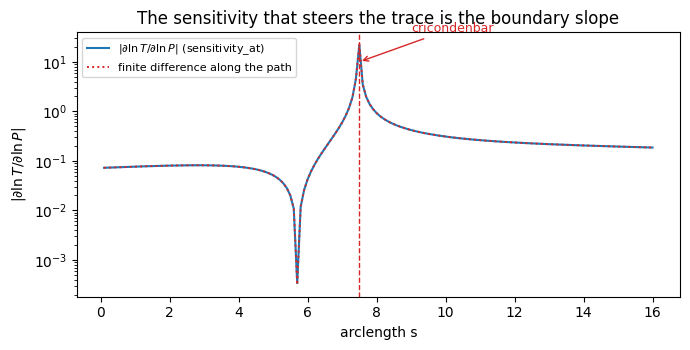

In [13]:
zn = jnp.zeros(N + 1)
ks = np.arange(2, len(tr.s) - 2, 2)
dlnT_dlnP = np.array([
    float(np.asarray(jp.sensitivity_at(jnp.asarray(tr.x[k]),
                                       jnp.array([float(tr.theta[k])]),
                                       (jnp.zeros(N + 1), zn, zn))).reshape(-1)[N])
    for k in ks])
fd = np.array([(tr.x[k+1, N] - tr.x[k-1, N]) / (tr.theta[k+1] - tr.theta[k-1]) for k in ks])

good = np.abs(fd) < 50
rel = np.max(np.abs(dlnT_dlnP[good] - fd[good]) / (1.0 + np.abs(fd[good])))
print(f"sensitivity_at vs finite difference along the path: max rel err = {rel:.2e}")
print(f"  (finite differencing a curved path at ds=0.05 is the less accurate of the two)")
print()
k_cb = int(np.argmin(np.abs(ks - icb)))
print(f"|dlnT/dlnP| on the low-pressure dew branch : {abs(dlnT_dlnP[1]):.3f}")
print(f"|dlnT/dlnP| nearest the cricondenbar       : {abs(dlnT_dlnP[k_cb]):.1f}"
      f"   ({abs(dlnT_dlnP[k_cb])/abs(dlnT_dlnP[1]):.0f}x larger, and unbounded at the fold)")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.semilogy(tr.s[ks], np.abs(dlnT_dlnP), "-", color="C0", label=r"|$\partial\ln T/\partial\ln P$| (sensitivity_at)")
ax.semilogy(tr.s[ks], np.abs(fd), ":", color="C3", lw=1.4, label="finite difference along the path")
ax.axvline(tr.s[icb], color="C3", ls="--", lw=1)
ax.annotate("cricondenbar", xy=(tr.s[icb], 10), xytext=(tr.s[icb] + 1.5, 40),
            arrowprops=dict(arrowstyle="->", color="C3"), fontsize=9, color="C3")
ax.set_xlabel("arclength s")
ax.set_ylabel(r"$|\partial \ln T / \partial \ln P|$")
ax.set_title("The sensitivity that steers the trace is the boundary slope")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 11. Retrograde condensation

The physical payoff of the fold. For a temperature between the critical temperature and
the cricondentherm, a *vertical* line crosses the dew branch **twice** — so lowering the
pressure at fixed temperature makes liquid appear and then disappear again. That is
retrograde condensation, and it is why gas-condensate reservoirs drop liquid as they are
produced.

A method that could only march up in pressure would have found the first of each pair and
stopped.

In [14]:
dew = slice(0, icrit)
print(f"{'T (K)':>8}   dew pressures (bar)")
print("-" * 34)
for Tq in [255.0, 265.0, 275.0]:
    hits = [0.5 * (P[i] + P[i + 1]) for i in range(icrit - 1)
            if (T[i] - Tq) * (T[i + 1] - Tq) < 0]
    print(f"{Tq:8.1f}   {'  and  '.join(f'{p:.1f}' for p in sorted(hits))}")
print(f"\ncritical T = {T_crit:.1f} K,  cricondentherm = {T.max():.1f} K")
print("between those two temperatures every isotherm meets the dew branch twice.")

   T (K)   dew pressures (bar)
----------------------------------
   255.0   10.8  and  96.5
   265.0   17.4  and  97.2
   275.0   28.7  and  91.4

critical T = 246.3 K,  cricondentherm = 283.9 K
between those two temperatures every isotherm meets the dew branch twice.


## 12. Verification

Every claim above, as a number.

In [15]:
res_all = np.array([float(jnp.max(jnp.abs(envelope_residual(jnp.asarray(x), float(t), BETA))))
                    for x, t in zip(tr.x, tr.theta)])
print(f"1. max|F| over all {len(res_all)} traced points        : {res_all.max():.2e}")
assert res_all.max() < 1e-8

d_tp = abs(np.exp(trT.turning_points[0]) - T.max())
d_pb = abs(np.exp(tr.turning_points[0]) / 1e5 - P_T.max())
print(f"2. cricondentherm, two parameterizations       : {d_tp:.3f} K apart")
print(f"   cricondenbar,   two parameterizations       : {d_pb:.3f} bar apart")
assert d_tp < 0.5 and d_pb < 0.5

print(f"3. critical point, max|K_i - 1|                : "
      f"{np.max(np.abs(np.exp(tr.x[icrit, :N]) - 1.0)):.2e}")
assert np.max(np.abs(np.exp(tr.x[icrit, :N]) - 1.0)) < 0.01

print(f"4. sensitivity_at vs finite difference         : {rel:.2e} rel")
assert rel < 0.1

k_before, k_after = np.exp(tr.x[icrit - 25, 0]), np.exp(tr.x[icrit + 25, 0])
print(f"5. K_methane inverts across the critical point : {k_before:.3f} -> {k_after:.3f}")
assert k_before > 1.0 > k_after

n_two = sum(len([1 for i in range(icrit - 1) if (T[i] - Tq) * (T[i + 1] - Tq) < 0]) == 2
            for Tq in [255.0, 265.0, 275.0])
print(f"6. isotherms with two dew pressures (of 3)     : {n_two}")
assert n_two == 3

print(f"7. ladder died at                              : "
      f"{last_good[0]:.2f} bar vs cricondenbar {P.max():.2f} bar")
print(f"8. follow() landed on max|lnK| =               : "
      f"{np.max(np.abs(tr_follow.x[-1, :N])):.1e}  (the trivial branch)")
print("\nall checks passed")

1. max|F| over all 324 traced points        : 9.85e-10
2. cricondentherm, two parameterizations       : 0.020 K apart
   cricondenbar,   two parameterizations       : 0.000 bar apart
3. critical point, max|K_i - 1|                : 3.86e-03
4. sensitivity_at vs finite difference         : 2.46e-02 rel
5. K_methane inverts across the critical point : 1.241 -> 0.906
6. isotherms with two dew pressures (of 3)     : 3
7. ladder died at                              : 97.00 bar vs cricondenbar 97.58 bar
8. follow() landed on max|lnK| =               : 3.5e-15  (the trivial branch)

all checks passed


## 13. When to reach for which

| Situation | Use | What happened here |
|---|---|---|
| Parameter sweep, no folds, active set may change | `PathFollower.follow` | Worked below the fold, then **silently** converged to the trivial branch |
| Re-solve at each parameter value | plain `jp.solve` in a loop | Failed loudly at the cricondenbar — correct behaviour, no solution exists |
| The path folds in the parameter | `PathFollower.trace_arclength` | Traced the entire envelope, both turning points detected |

Three things worth carrying away:

**A square system is a feasibility NLP.** `min 0` s.t. `F(X) = 0` with `n == m`, and the
IPM step reduces to the Newton step. No separate root-finder needed.

**Check for trivial branches yourself.** No solver can know that $K \equiv 1$ is
physically vacuous — it satisfies the equations exactly. A residual of $10^{-15}$ is not
evidence that an answer means anything. Here the guard is one line: `max|ln K|` must not
collapse away from the critical point.

**Turning points are output.** The cricondenbar and cricondentherm were not searched for;
they fell out of `PathTrace.turning_points` because the continuation noticed the tangent
reverse. They are located to the `ds` sampling resolution, so tighten `ds` if the value
itself matters.

### Limits

The trace stops on its own at the cold end of the bubble branch, where the heavy
components' $K$-values run past a few hundred and the corrector can no longer take a full
`ds` step; the envelope is complete well before that. `trace_arclength` requires a scalar
parameter and equality constraints, and general **branch switching is out of scope** — the
critical point here is a place where the physical and trivial branches meet, and the trace
stays on the physical one because it follows a tangent rather than re-solving. Do not
assume that holds for every system with a trivial solution.

### See also

- [Path Following & Inverse Mapping](https://kitchingroup.cheme.cmu.edu/pounce/path-following.html) — `follow`, `trace_arclength`, `inverse_map_rhs`
- [`14_path_following.ipynb`](14_path_following.ipynb) — the same machinery with analytic checks
- [Sensitivity Analysis](https://kitchingroup.cheme.cmu.edu/pounce/sensitivity.html) — where $\partial x^*/\partial\theta$ comes from
- [Boundary Value Problems](https://kitchingroup.cheme.cmu.edu/pounce/bvp.html) — the `min 0` square-system idiom used here